# Prepare Data for Cell2Net Training on PBMC

This tutorial demonstrates the comprehensive data preparation pipeline for Cell2Net training using Peripheral Blood Mononuclear Cells (PBMC) multiome data. We'll transform raw single-cell measurements into analysis-ready datasets optimized for regulatory network modeling.

## Overview

Cell2Net requires carefully prepared multiome data that integrates:
1. **Gene expression profiles** (RNA-seq) 
2. **Chromatin accessibility** (ATAC-seq)
3. **DNA sequence information** for regulatory regions
4. **Transcription factor motif annotations**
5. **Peak-to-gene regulatory relationships**

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import scanpy as sc
import mudata as md
import cell2net as cn

md.set_options(pull_on_update=False)

In [3]:
cn.__version__

'0.13'

## Load Raw PBMC Multiome Data

Import the preprocessed PBMC multiome dataset containing paired RNA-seq and ATAC-seq measurements. This dataset represents the full cellular diversity of the peripheral blood immune system.

In [4]:
mdata = md.read_h5mu(f'./mdata.h5mu')

Examine the structure and dimensions of our multiome dataset:

In [5]:
mdata

MuData object with n_obs × n_vars = 11131 × 131516
  obs:	'cell_type', 'cell_type_v2', 'total_counts_rna', 'total_counts_atac', 'total_counts_rna_log', 'total_counts_atac_log'
  2 modalities
    rna:	11131 x 15932
      obs:	'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'cell_type_v2'
      var:	'genes', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'cell_type_colors', 'cell_type_v2_colors', 'hvg'
      obsm:	'X_umap'
      layers:	'counts'
    atac:	11131 x 115584
      obs:	'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'cell_type_v2'
      var:	'peaks', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      uns:	'cell_type_colors', 'cell_type_v2_colors'
      obsm:	'X_umap'
      layers:	'counts'

## RNA Data Preprocessing

Apply standard single-cell RNA-seq normalization and dimensionality reduction:

1. **Total count normalization**: Scale gene expression to account for sequencing depth differences
2. **Log transformation**: Stabilize variance and make data more normally distributed  
3. **Principal Component Analysis**: Reduce dimensionality while preserving major expression patterns

This preprocessing is essential for identifying highly variable genes and computing cellular similarities.

In [6]:
sc.pp.normalize_total(mdata['rna'])
sc.pp.log1p(mdata['rna'])
sc.tl.pca(mdata['rna'], n_comps=30, use_highly_variable=True)

## Visualize Cellular Diversity

Explore the immune cell populations and their marker gene expression patterns. This visualization helps us understand:
- **Cell type distribution**: Major immune populations (T cells, B cells, monocytes, etc.)
- **Marker gene expression**: TCF4 (B cell/pDC marker) and IRF8 (myeloid/DC marker)
- **Data quality**: Well-separated cell types indicate good data quality

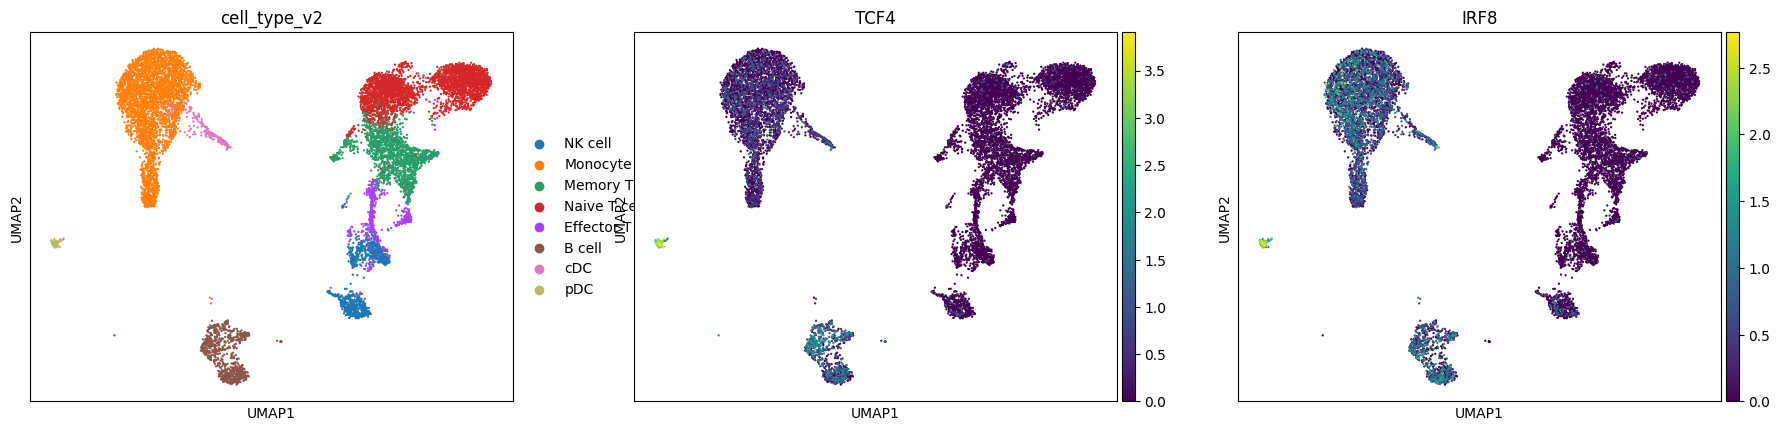

In [7]:
sc.pl.umap(mdata["rna"], color=["cell_type_v2", "TCF4", "IRF8"])

## Create Metacells for Network Modeling

Generate metacells to aggregate similar single cells for improved Cell2Net training:

### **Why Metacells?**
- **Noise reduction**: Average out technical variability while preserving biological signal
- **Computational efficiency**: Reduce dataset size from ~10K cells to 1K metacells
- **Statistical power**: Improve signal-to-noise ratio for regulatory relationships
- **Cell type preservation**: Maintain representation of all immune populations

### **Metacell Generation Process**:
1. **Similarity calculation**: Use PCA and nearest neighbor graphs
2. **Community detection**: Group similar cells using clustering algorithms  
3. **Expression aggregation**: Average gene expression within each metacell
4. **Quality control**: Ensure metacells represent coherent cell states

In [8]:
mdata_bulk = cn.tl.get_metacells(mdata, n_metacells=1000)

2025-11-28 17:53:06 INFO     Total number of metacells to create: 1000
2025-11-28 17:53:07 INFO     Select 1000 metacells using geosketch
2025-11-28 17:53:07 INFO     Select 1000 metacells using geosketch
2025-11-28 17:53:08 INFO     No groupby provided, using all cells
2025-11-28 17:53:08 INFO     Create KNN graph with X_pca and 15 neighbors
2025-11-28 17:53:08 INFO     No groupby provided, using all cells
2025-11-28 17:53:08 INFO     Create KNN graph with X_pca and 15 neighbors
2025-11-28 17:57:32 INFO     Done
2025-11-28 17:57:32 INFO     Done


Examine the metacell metadata and cell type composition:

In [9]:
mdata_bulk.obs

,cell_type,cell_type_v2,total_counts_rna,total_counts_atac,total_counts_rna_log,total_counts_atac_log
AAACAGCCAGTAGGTG-1,naive CD4 T cells,Naive T cell,7598.0,35084.0,3.880699,4.545109
AAACATGCAAGGTCCT-1,naive CD8 T cells,Naive T cell,3238.0,21146.0,3.510277,4.325228
AAACCAACATAATCCG-1,classical monocytes,Monocyte,7947.0,36882.0,3.900203,4.566814
AAACCGAAGTGAGCAA-1,CD56 (dim) NK cells,NK cell,1295.0,13810.0,3.112270,4.140194
AAACCGGCATAATCAC-1,myeloid DC,cDC,7216.0,25034.0,3.858297,4.398530
...,...,...,...,...,...,...
TTTGTCCCAGCTACGT-1,effector CD8 T cells,Effector T cell,4358.0,16815.0,3.639287,4.225697
TTTGTCTAGACAACAG-1,memory B cells,B cell,6463.0,39713.0,3.810434,4.598933
TTTGTCTAGAGAGCCG-1,effector CD8 T cells,Effector T cell,2749.0,23267.0,3.439175,4.366740
TTTGTGGCAGTTTGTG-1,classical monocytes,Monocyte,2165.0,18096.0,3.335458,4.257583


Check the dimensions of our metacell dataset:

In [10]:
mdata_bulk

MuData object with n_obs × n_vars = 1000 × 131516
  obs:	'cell_type', 'cell_type_v2', 'total_counts_rna', 'total_counts_atac', 'total_counts_rna_log', 'total_counts_atac_log'
  2 modalities
    rna:	1000 x 15932
      obs:	'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'cell_type_v2'
      var:	'genes', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      layers:	'counts'
    atac:	1000 x 115584
      obs:	'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'cell_type_v2'
      var:	'peaks', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      layers:	'counts'

## Process and Visualize Metacells

Apply dimensionality reduction to metacells for quality assessment and visualization:

1. **Re-normalize**: Account for aggregation effects in metacells
2. **PCA**: Capture main expression variation patterns  
3. **Neighborhood graph**: Build cell similarity network
4. **UMAP embedding**: Create 2D visualization of metacell relationships

This processing ensures metacells maintain the biological structure of the original data while providing noise reduction benefits.

In [11]:
# visualize metacells
sc.pp.normalize_total(mdata_bulk['rna'])
sc.tl.pca(mdata_bulk['rna'], n_comps=30, use_highly_variable=True)
sc.pp.neighbors(mdata_bulk['rna'])
sc.tl.umap(mdata_bulk['rna'])

### Validate Metacell Quality

Visualize metacells colored by cell type and marker genes to ensure:
- **Cell type preservation**: Each metacell maintains coherent cell identity
- **Marker gene expression**: Key lineage markers (TCF4, IRF8, IRF1) show expected patterns
- **Spatial organization**: Similar cell types cluster together in UMAP space
- **Reduced noise**: Smoother expression patterns compared to single cells

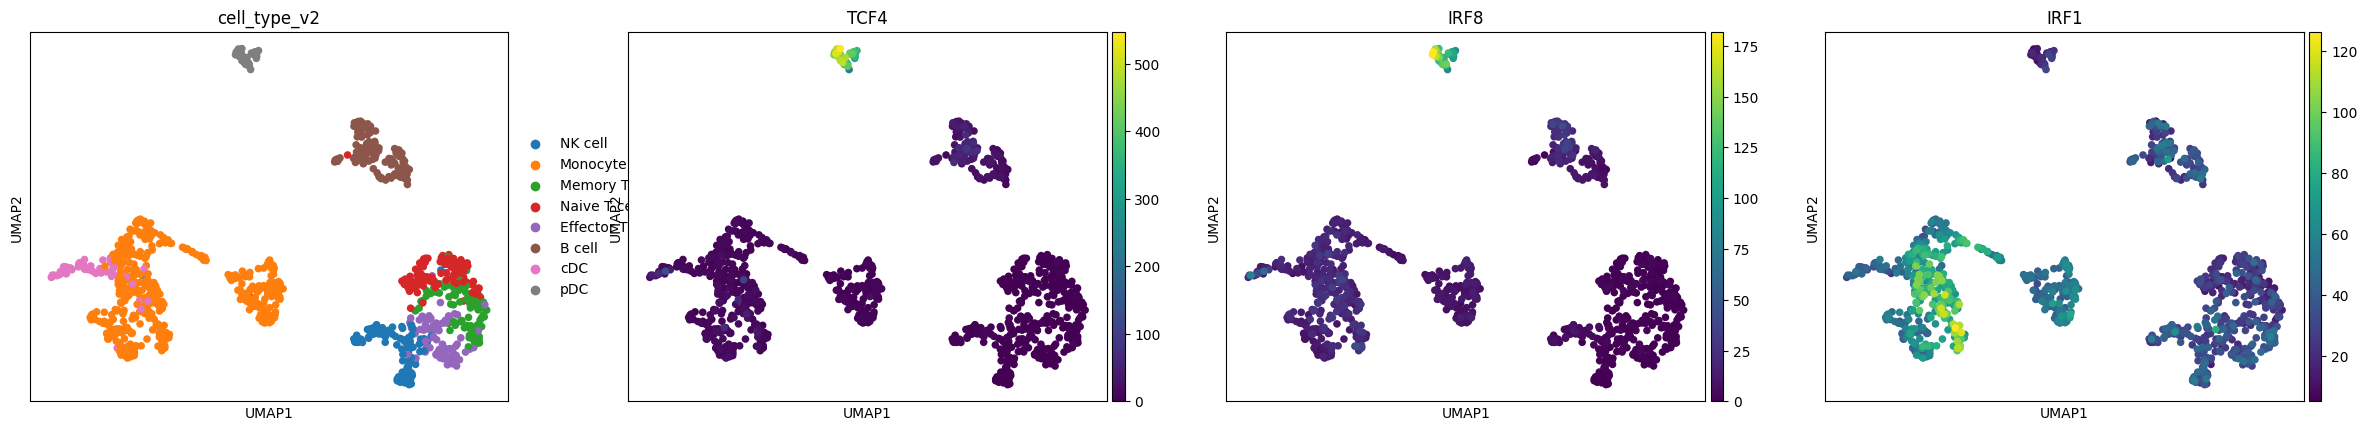

In [12]:
sc.pl.umap(mdata_bulk['rna'], color=["cell_type_v2", "TCF4", "IRF8", "IRF1"])

## Add Genomic Annotations

Integrate essential genomic information for Cell2Net modeling:

### **1. Gene TSS Coordinates**
- Extract transcription start site (TSS) positions from GTF annotation
- Define promoter regions for regulatory analysis
- Enable distance-based peak-to-gene associations

### **2. Peak Sequence Extraction** 
- Define 256bp windows around ATAC-seq peaks
- Extract DNA sequences from reference genome
- Prepare sequence data for attention mechanisms

### **3. DNA Sequence Integration**
- Link each accessibility peak with its DNA sequence
- Enable sequence-guided regulatory modeling
- Support motif-based feature extraction

This genomic annotation is crucial for Cell2Net's sequence-aware architecture.

In [13]:
cn.pp.add_gene_tss_coord(mdata_bulk, gene_gtf='../../../../data/refdata-gex-GRCh38-2020-A/genes/genes.gtf.gz')
cn.pp.add_peaks(mdata_bulk, mod_name='atac', peak_len=256)
cn.pp.add_dna_sequence(mdata_bulk, ref_fasta='../../../../data/refdata-gex-GRCh38-2020-A/fasta/genome.fa')

2025-11-28 17:57:35 INFO     Adding gene TSS coordinates from ../../../../data/refdata-gex-GRCh38-2020-A/genes/genes.gtf.gz to rna modality.
Fetching sequences: 100%|██████████| 115584/115584 [00:00<00:00, 270279.52it/s]



## Load and Filter Transcription Factor Motifs

Prepare transcription factor binding site motifs for regulatory analysis:

### **Motif Database (JASPAR2024)**:
- Comprehensive collection of experimentally validated TF binding motifs  
- Position weight matrices (PWMs) for sequence scanning
- Covers major transcription factor families relevant to immune cells

### **Gene-Based Filtering**:
- Retain only motifs for TFs expressed in our PBMC dataset
- Reduces computational complexity and focuses on relevant regulators
- Ensures TF-target relationships are biologically plausible

This curated motif set enables identification of functional TF binding sites in accessible chromatin regions.

In [14]:
motifs = cn.pp.get_tf_motifs(database='JASPAR2024')
cn.pp.filter_motifs_by_genes(motifs, mdata_bulk)

2025-11-28 17:57:47 INFO     Number of motifs fetched: 879
2025-11-28 17:57:47 INFO     Number of motifs overlapped with genes: 390
2025-11-28 17:57:47 INFO     Number of motifs overlapped with genes: 390


## Scan for Transcription Factor Binding Sites

Identify TF binding sites within accessible chromatin regions:

### **Motif Matching Process**:
1. **Sequence scanning**: Apply TF motifs to DNA sequences of ATAC-seq peaks
2. **Score calculation**: Compute binding affinity scores based on position weight matrices
3. **Threshold filtering**: Retain high-confidence binding site predictions
4. **Genomic annotation**: Map binding sites to peaks and nearby genes

### **Output**: 
- Binary matrix indicating TF binding site presence/absence in each peak
- Quantitative scores for binding site strength
- Spatial relationships between TFs, peaks, and target genes

This motif matching provides mechanistic links between TF activity and chromatin accessibility for Cell2Net modeling.

In [15]:
cn.pp.match_motif(mdata_bulk, motifs)

2025-11-28 17:57:47 INFO     Matching TF motifs
Scanning motifs: 100%|██████████| 115584/115584 [04:24<00:00, 436.75it/s]

2025-11-28 18:02:28 INFO     Motif matching is done!
2025-11-28 18:02:28 INFO     Motif matching is done!


## Establish Peak-to-Gene Regulatory Links

Create the core regulatory network by linking accessible chromatin regions to target genes:

### **Peak-to-Gene Mapping Strategy**:
1. **Distance-based associations**: Link peaks to nearby genes within reasonable genomic windows
2. **Correlation analysis**: Compute associations between peak accessibility and gene expression across metacells
3. **Sequence-guided refinement**: Use DNA sequence features to improve link predictions
4. **Statistical significance**: Apply multiple testing correction for robust associations

### **Key Parameters**:
- **min_n_peaks=3**: Require minimum peak count per gene for reliable modeling
- **highly_variable=True**: Focus on genes with informative expression variation
- **inplace=True**: Store results directly in the MuData object

### **Output**: 
Peak-to-gene association matrix forming the foundation for Cell2Net's attention-based regulatory modeling.

In [16]:
cn.pp.peak_to_gene(mdata_bulk,
                   ref_fasta='../../../../data/refdata-gex-GRCh38-2020-A/fasta/genome.fa',
                   min_n_peaks=3,
                   highly_variable=True,
                   gene_name_col="genes",
                   inplace=True)

2025-11-28 18:02:28 INFO     Fetching TSS coordinates
2025-11-28 18:02:28 INFO     Using highly variable genes
2025-11-28 18:02:28 INFO     Using highly variable genes
2025-11-28 18:02:28 INFO     Number of genes: 2000
2025-11-28 18:02:28 INFO     Number of genes: 2000
2025-11-28 18:02:28 INFO     Number of peaks: 115584
2025-11-28 18:02:28 INFO     Linking genes to nearby peaks
2025-11-28 18:02:28 INFO     Number of peaks: 115584
2025-11-28 18:02:28 INFO     Linking genes to nearby peaks
Linking genes to peaks: 100%|██████████| 2000/2000 [00:49<00:00, 40.43it/s]

2025-11-28 18:03:18 INFO     Number of genes that have at least 3 peaks: 1927
2025-11-28 18:03:18 INFO     Number of genes that have at least 3 peaks: 1927
2025-11-28 18:03:18 INFO     Identified 128067 potential peak-to-gene links
2025-11-28 18:03:18 INFO     Identified 128067 potential peak-to-gene links


## Construct TF-to-Gene Regulatory Networks

Build transcription factor regulatory networks by integrating motif information with peak-to-gene links:

### **TF-Gene Network Construction**:
1. **Motif-peak associations**: Identify which TFs have binding sites in each peak
2. **Peak-gene links**: Use previously computed peak-to-gene associations  
3. **Transitive relationships**: Connect TFs to genes via their binding peaks
4. **Network aggregation**: Combine multiple TF-peak-gene paths into regulatory scores

### **Regulatory Logic**:
```
TF → Binding Site (in Peak) → Accessible Chromatin → Target Gene Expression
```

### **Output**:
- TF-to-gene regulatory network matrix
- Regulatory scores reflecting potential influence strength  
- Mechanistic basis for understanding gene expression control

This network provides Cell2Net with biologically-informed priors about transcriptional regulation in immune cells.

In [17]:
cn.pp.tf_to_gene(mdata_bulk)

2025-11-28 18:03:18 INFO     Linking potential TFs for each gene
Finding TFs: 100%|██████████| 1927/1927 [00:42<00:00, 45.29it/s]


## Prepare Metadata and Covariates

Consolidate essential metadata for Cell2Net training:

### **Key Metadata Integration**:
1. **Cell type annotations**: Preserve immune cell population identities
2. **Count statistics**: Total RNA and ATAC counts per metacell for quality control
3. **Cross-modal integration**: Ensure consistent cell identifiers across RNA and ATAC modalities

### **Quality Control Metrics**:
- **total_counts_rna**: Total gene expression per metacell (sequencing depth)
- **total_counts_atac**: Total accessibility counts per metacell (data quality)
- **cell_type information**: Biological context for model interpretation

This consolidated metadata enables Cell2Net to account for technical factors while modeling biological regulatory relationships.

In [18]:
df_obs_rna = mdata_bulk['rna'].obs[['cell_type', 'cell_type_v2', 'total_counts']]
df_obs_rna = df_obs_rna.rename(columns={'total_counts': 'total_counts_rna'})

df_obs_atac = mdata_bulk['atac'].obs[['total_counts']]
df_obs_atac = df_obs_atac.rename(columns={'total_counts': 'total_counts_atac'})

df_obs = pd.concat([df_obs_rna, df_obs_atac], axis=1)

mdata_bulk.obs = df_obs.copy()

## Add Log-Transformed Covariates

Create log-transformed versions of count statistics for model training:

### **Model Covariates**:
- **total_counts_rna_log**: Accounts for RNA sequencing depth variation
- **total_counts_atac_log**: Accounts for ATAC-seq technical differences

These covariates allow Cell2Net to separate technical effects from true biological regulatory relationships.

In [19]:
mdata_bulk.obs['total_counts_rna_log'] = np.log10(mdata_bulk.obs['total_counts_rna'])
mdata_bulk.obs['total_counts_atac_log'] = np.log10(mdata_bulk.obs['total_counts_atac'])

## Save Processed Dataset

Export the fully prepared MuData object containing all components needed for Cell2Net training:

### **Saved Components**:
- **Metacell expression profiles** (RNA and ATAC)
- **Genomic annotations** (gene TSS coordinates, peak sequences)
- **Regulatory networks** (peak-to-gene and TF-to-gene associations)
- **Motif annotations** (TF binding site predictions)
- **Metadata and covariates** (cell types, count statistics)

This comprehensive dataset is now ready for Cell2Net model training and regulatory network inference.

In [20]:
out_dir = "./02_prepare_data"
os.makedirs(out_dir, exist_ok=True)

In [21]:
mdata_bulk.write_h5mu(f'{out_dir}/mdata.h5mu')

## Export Motif Annotations

Save transcription factor binding site predictions in standard BED format for external analysis and visualization:

### **BED File Contents**:
- **Genomic coordinates** of predicted TF binding sites
- **TF identity** for each binding site
- **Binding scores** indicating prediction confidence
- **Peak associations** linking motifs to accessible regions

This standardized format enables integration with genome browsers, ChIP-seq validation data, and other genomic analysis tools.

In [22]:
# save motif match results to a bed file
motif_bed = mdata_bulk['atac'].uns['motif_match']
motif_bed.to_csv(f'{out_dir}/motif_match.bed', sep='\t', index=False, header=False)

## Summary and Next Steps

### ✅ **Data Preparation Complete**:

1. **Single-cell to metacells**: Aggregated ~10K cells to 1K metacells for noise reduction
2. **Genomic annotation**: Added gene TSS coordinates and DNA sequences for all peaks
3. **Motif analysis**: Identified TF binding sites in accessible chromatin regions  
4. **Regulatory networks**: Established peak-to-gene and TF-to-gene associations
5. **Quality control**: Prepared covariates for technical factor correction
6. **Data export**: Saved comprehensive dataset for Cell2Net training

### 🎯 **Key Outputs**:
- **mdata.h5mu**: Complete multiome dataset with all annotations
- **motif_match.bed**: TF binding site predictions in BED format
- **Regulatory networks**: Peak-gene and TF-gene association matrices
- **Metadata**: Cell type labels and quality control metrics

The comprehensive data preparation pipeline established here provides a robust foundation for understanding immune cell regulation through sequence-guided regulatory network modeling with Cell2Net.